<a href="https://colab.research.google.com/github/NatShed/MO_Attack/blob/main/lab7_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 7. Анализ устойчивости ML-моделей в чёрно-ящичном сценарии

### Transfer-based, score-based и decision-based подходы

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 5**


**Вариант / seed:** Индивидуальные значения не выданы
> Работа выполняется только на предоставленной синтетической модели. Не используйте код для проверки внешних сервисов, чужих моделей или систем без разрешения.

## 1. Цель работы

Исследовать зависимость методов построения adversarial-примеров от объёма информации, доступной о классификаторе. Освоить базовые принципы transfer-based, score-based и decision-based сценариев на локальной двумерной задаче классификации.

## 2. Задачи

1. Сформировать синтетический набор данных и обучить target-модель.
2. Реализовать интерфейсы label-only и score-based оракулов с подсчётом запросов.
3. Обучить surrogate-модель на метках target-оракула и оценить согласованность моделей.
4. Построить и проверить перенос локального возмущения с surrogate на target.
5. Сравнить ZOO и NES по направлению оценки и числу запросов.
6. Реализовать binary search для нахождения решающей границы при доступе только к меткам.
7. Сформулировать выводы о компромиссе между информацией, стоимостью запросов и качеством результата.

## 3. Краткая теория

| Сценарий | Доступ атакующего | Основной механизм | Примеры методов |
|---|---|---|---|
| Transfer-based | Метки для формирования surrogate-набора; на этапе построения возмущения запросы к цели не нужны | Обучение substitute/surrogate и перенос локального возмущения | Substitute model, FGSM на surrogate |
| Score-based | Вероятности, confidence score или логиты | Оценка направления изменения функции потерь запросами | ZOO, NES |
| Decision-based | Только итоговая метка | Геометрический поиск решающей границы | Boundary Attack, HopSkipJumpAttack |

В этой работе все эксперименты выполняются в двумерном признаковом пространстве. Это позволяет визуализировать границы и траектории. Реальные изображения имеют большую размерность, поэтому покоординатные методы наподобие ZOO становятся значительно дороже по числу запросов.

## 4. Среда выполнения

Необходимые библиотеки:

```bash
pip install numpy matplotlib scikit-learn
```

Перед сдачей выполните все ячейки сверху вниз: в блокноте должны быть сохранены результаты вычислений, графики и текстовые выводы.

# Часть A. Подготовка эксперимента

## A1. Импорт библиотек и параметры

Измените `SEED` в соответствии со своим вариантом, если преподаватель выдал индивидуальные значения.

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

SEED = 42 # не выдан индивидуальный вариант
rng = np.random.default_rng(SEED)

N_SAMPLES = 1000
NOISE = 0.22
TEST_SIZE = 0.35

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## A2. Формирование данных и обучение target-модели

Target-модель рассматривается как неизвестная для атакующего. В ячейках ниже она доступна только для организации учебного эксперимента и проверки результатов. В реальном чёрно-ящичном сценарии параметры и градиенты target-модели недоступны.

**Задание A2.** Запустите ячейку. Зафиксируйте точность target-модели в отчёте. Затем измените `NOISE` на 0.10 и 0.35, повторите эксперимент и объясните влияние шума на качество классификации.

In [123]:
X_raw, y = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=SEED)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
)

scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

target = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='tanh',
    alpha=2e-4,
    max_iter=1500,
    random_state=SEED
).fit(X_train, y_train)

target_accuracy = accuracy_score(y_test, target.predict(X_test))
print(f'Точность target-модели: {target_accuracy:.3f}')

Точность target-модели: 0.974


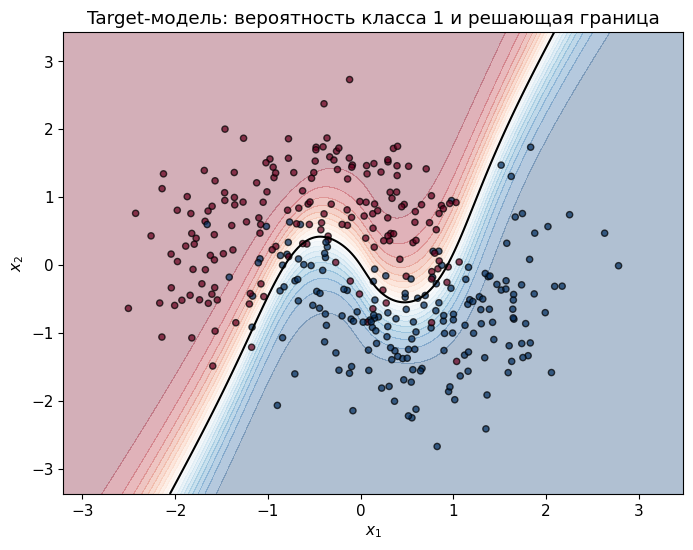

In [146]:
def make_grid(X, n=300, margin=0.7):
    x0_min, x0_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    x1_min, x1_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, n),
        np.linspace(x1_min, x1_max, n)
    )
    return xx, yy, np.c_[xx.ravel(), yy.ravel()]


def plot_boundary(model, X, y, title, ax=None, points=None, labels=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    xx, yy, grid = make_grid(X)
    proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, proba, levels=np.linspace(0, 1, 21), cmap='RdBu', alpha=0.32)
    ax.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=1.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolor='k', s=20, alpha=0.72)

    if points is not None:
        points = np.asarray(points)
        ax.scatter(points[:, 0], points[:, 1], c='gold',
                   edgecolor='black', s=120, zorder=5)
        if labels is not None:
            for point, label in zip(points, labels):
                ax.annotate(label, point, xytext=(7, 7),
                            textcoords='offset points', weight='bold')

    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    return ax

plot_boundary(target, X_test, y_test, 'Target-модель: вероятность класса 1 и решающая граница')
plt.show()

Точность target-модели: 0.997 при шуме: 0.1


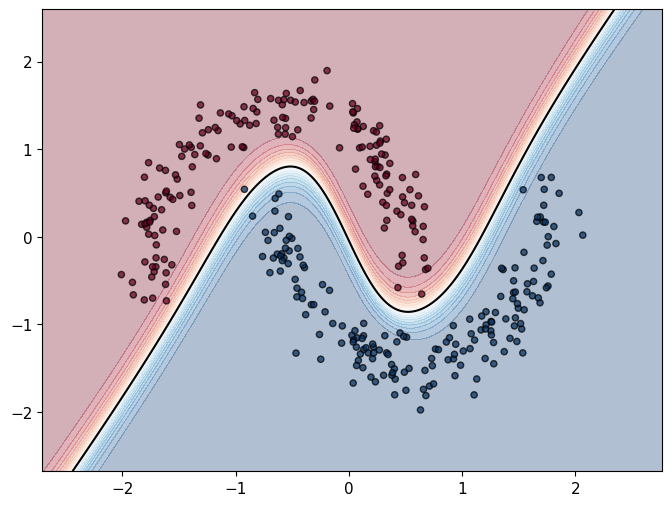

Точность target-модели: 0.886 при шуме: 0.35


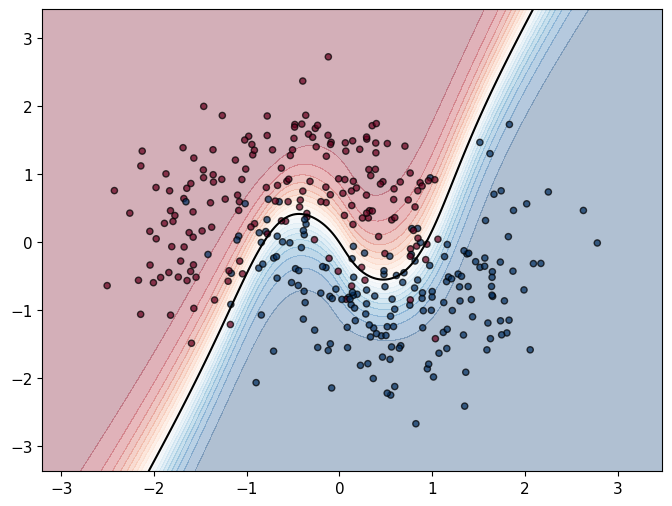

In [125]:
noise_level = [0.10, 0.35]
for n in noise_level:
  X_raw, y = make_moons(n_samples=N_SAMPLES, noise=n, random_state=SEED)
  X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
  )

  scaler = StandardScaler().fit(X_train_raw)
  X_train = scaler.transform(X_train_raw)
  X_test = scaler.transform(X_test_raw)

  target = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='tanh',
    alpha=2e-4,
    max_iter=1500,
    random_state=SEED
).fit(X_train, y_train)

  target_accuracy = accuracy_score(y_test, target.predict(X_test))
  print(f'Точность target-модели: {target_accuracy:.3f} при шуме: {n}')

  def make_grid(X, n=300, margin=0.7):
      x0_min, x0_max = X[:, 0].min() - margin, X[:, 0].max() + margin
      x1_min, x1_max = X[:, 1].min() - margin, X[:, 1].max() + margin
      xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, n),
        np.linspace(x1_min, x1_max, n)
       )
      return xx, yy, np.c_[xx.ravel(), yy.ravel()]


  def plot_boundary(model, X, y, title, ax=None, points=None, labels=None):
      if ax is None:
          fig, ax = plt.subplots(figsize=(8, 6))
          xx, yy, grid = make_grid(X)
          proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)
          ax.contourf(xx, yy, proba, levels=np.linspace(0, 1, 21), cmap='RdBu', alpha=0.32)
          ax.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=1.5)
          ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolor='k', s=20, alpha=0.72)
          if points is not None:
              points = np.asarray(points)
              ax.scatter(points[:, 0], points[:, 1], c='gold', edgecolor='black', s=120, zorder=5)
          if labels is not None:
              for point, label in zip(points, labels):
                    ax.annotate(label, point, xytext=(7, 7), textcoords='offset points', weight='bold')
                    ax.set_title(title)
                    ax.set_xlabel('$x_1$')
                    ax.set_ylabel('$x_2$')
          return ax

  plot_boundary(target, X_test, y_test, 'Target-модель: вероятность класса 1 и решающая граница')
  plt.show()

**Вывод по A2 (заполните после эксперимента):**

_Точность target-модели при `NOISE = 0,1` составила 0,997, при `NOISE = 0,22`  — 0.974, при `NOISE = 0,35`  — 0.886. При увеличении шума точность монотонно падает: с 0.997 до 0.886 — снижение на 11.1 п.п. Это объясняется тем, что шум перемешивает точки двух классов вблизи решающей границы. При малом шуме (0.10) луны чётко разделимы — модель легко проводит между ними границу и почти не ошибается (0.997). При большом шуме (0.35) точки класса 0 и класса 1 перекрываются — часть объектов оказывается «на чужой территории», и любая граница будет ошибаться на этих точках. Модель вынуждена балансировать между двумя классами, что снижает её точность. Чем больше шум, тем легче злоумышленнику, которому нужны меньшие возмущения для атаки, при маленьком шуме адверсариал примеры нужно искать далеко от границыю

# Часть B. Модели доступа к оракулу

## B1. Label-only и score-based оракулы

**Задание B1.** Запустите ячейку и сравните ответы двух оракулов. Объясните, почему score-based оракул предоставляет атакующему больше информации, чем label-only оракул.

In [126]:
class LabelOracle:
    def __init__(self, model):
        self.model = model
        self.queries = 0

    def __call__(self, X):
        X = np.atleast_2d(X)
        self.queries += len(X)
        return self.model.predict(X)


class ScoreOracle:
    def __init__(self, model):
        self.model = model
        self.queries = 0

    def __call__(self, X):
        X = np.atleast_2d(X)
        self.queries += len(X)
        return self.model.predict_proba(X)


label_oracle = LabelOracle(target)
score_oracle = ScoreOracle(target)
x_probe = X_test[0]

print('Точка x_probe:', np.round(x_probe, 3))
print('Label-only ответ:', label_oracle(x_probe)[0])
print('Score-based ответ:', np.round(score_oracle(x_probe)[0], 3))
print('Запросы: label-only =', label_oracle.queries, '; score-based =', score_oracle.queries)

Точка x_probe: [ 0.552 -1.09 ]
Label-only ответ: 1
Score-based ответ: [0.15 0.85]
Запросы: label-only = 1 ; score-based = 1


**Ответ на B1:**

Label-only оракул возвращает только итоговую метку класса, в нашем случае это 1, мы не знаем, насколько уверена модель. Score-based оракул дополнительно возвращает вероятности каждого класса, то есть мы сразу видим, что модель уверена, в классе 1 на 94%, также мы можем понять, насколько близко точка к грнице (чем ближе точка к границе, тем меньше разрыв между классами), мы можем сразу понять направления, куда нам двигаться, чтобы уменьшить/увеличить вероятность.

Поэтому в score-based сценарии можно оценивать градиент функции  потерь по входу через запросы, делаем малький шаг по каждой координате туда-обратно, смотрим, как меняются информации, понимаем направление атаки.

В label-only сценарии такой возможности нет: ответ 1 не меняется при малых изменениях точки (пока не пересечена граница), здесь придется использовать геометрический поиск (бинарный поиск границы), что требует больше запросов и менее точно.

Именно поэтому API, скрывающие вероятности (отдающие только метки), сложнее атаковать — атакующему приходится «щупать» границу вслепую.

# Часть C. Transfer-based сценарий

## C1. Обучение surrogate-модели

Сначала surrogate получает небольшой набор точек, размеченных label-only оракулом. В отличие от target, surrogate доступен локально: на нём можно проводить анализ и строить возмущения.

**Задание C1.** Выполните эксперимент при `N_SEED = 30`, `70` и `140`. Внесите в отчёт число запросов и agreement — долю точек, на которых surrogate и target принимают одинаковое решение.

Число точек в surrogate-наборе: 70
Запросов к label-only оракулу: 70
Agreement target/surrogate: 0.886


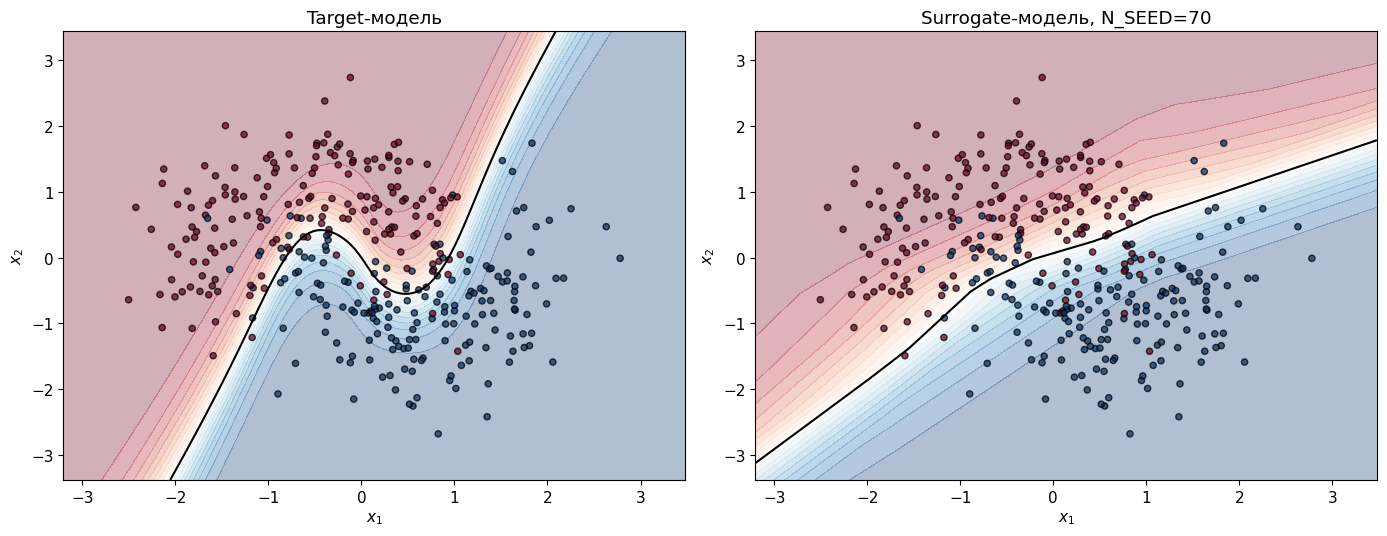

In [147]:
N_SEED = 70  # TODO: последовательно проверьте 30, 70 и 140

def train_surrogate(n_seed, random_state=SEED + 1):
    indices = rng.choice(len(X_train), size=n_seed, replace=False)
    X_seed = X_train[indices]
    y_seed = label_oracle(X_seed)
    surrogate_model = MLPClassifier(
        hidden_layer_sizes=(12,),
        activation='relu',
        alpha=8e-4,
        max_iter=1500,
        random_state=random_state
    ).fit(X_seed, y_seed)
    return surrogate_model, X_seed, y_seed

label_oracle.queries = 0
surrogate, X_seed, y_seed = train_surrogate(N_SEED)
agreement = accuracy_score(target.predict(X_test), surrogate.predict(X_test))

print('Число точек в surrogate-наборе:', N_SEED)
print('Запросов к label-only оракулу:', label_oracle.queries)
print('Agreement target/surrogate:', round(agreement, 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plot_boundary(target, X_test, y_test, 'Target-модель', ax=axes[0])
plot_boundary(surrogate, X_test, y_test, f'Surrogate-модель, N_SEED={N_SEED}', ax=axes[1])
plt.tight_layout()
plt.show()

N_SEED =  30 | queries =  30 | agreement = 0.869
N_SEED =  70 | queries =  70 | agreement = 0.903
N_SEED = 140 | queries = 140 | agreement = 0.891


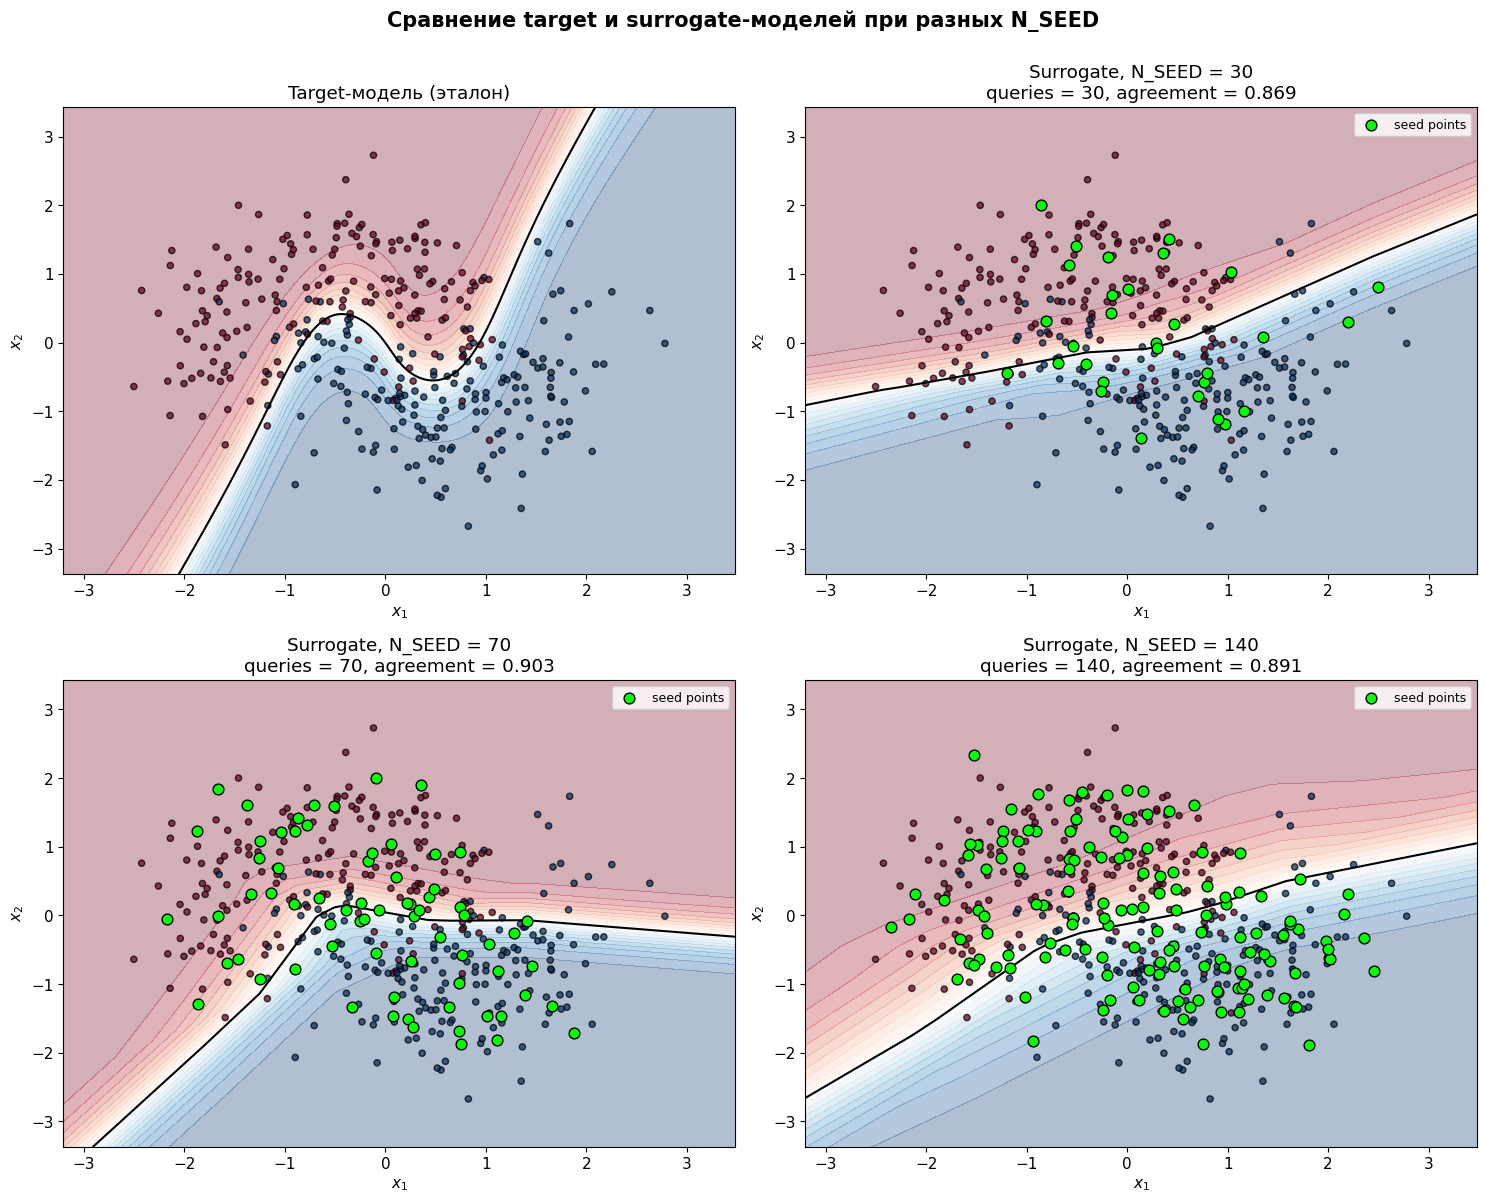

In [156]:
# ============================================================
# C1. Визуализация surrogate для N_SEED = 30, 70, 140
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

N_SEEDS = [30, 70, 140]
results = {}   # {n_seed: {"surrogate": model, "X_seed": ..., "y_seed": ..., "queries": ..., "agreement": ...}}

for n in N_SEEDS:
    # Сбрасываем счётчик запросов
    label_oracle.queries = 0

    # Обучаем surrogate на n точках (размеченных через оракул)
    surrogate_n, X_seed_n, y_seed_n = train_surrogate(n)

    # Считаем запросы и agreement
    q = label_oracle.queries
    agr = accuracy_score(target.predict(X_test), surrogate_n.predict(X_test))

    results[n] = {
        "surrogate": surrogate_n,
        "X_seed":    X_seed_n,
        "y_seed":    y_seed_n,
        "queries":   q,
        "agreement": agr,
    }

    print(f"N_SEED = {n:3d} | queries = {q:3d} | agreement = {agr:.3f}")


# ============================================================
# Графики: target + три surrogate (в сетке 2x2)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# --- Target ---
plot_boundary(
    target, X_test, y_test,
    "Target-модель (эталон)",
    ax=axes[0]
)

# --- Surrogate для каждого N_SEED ---
for i, n in enumerate(N_SEEDS, start=1):
    r = results[n]
    title = (f"Surrogate, N_SEED = {n}\n"
             f"queries = {r['queries']}, agreement = {r['agreement']:.3f}")
    plot_boundary(
        r["surrogate"], X_test, y_test,
        title,
        ax=axes[i]
    )
    # Отмечаем точки, на которых обучался surrogate
    axes[i].scatter(
        r["X_seed"][:, 0], r["X_seed"][:, 1],
        c='lime', edgecolor='black', s=60,
        marker='o', zorder=6, label='seed points'
    )
    axes[i].legend(loc='upper right', fontsize=9)

plt.suptitle("Сравнение target и surrogate-моделей при разных N_SEED",
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Таблица C1 для отчёта:**

| N_SEED | Запросов к оракулу | Agreement target/surrogate | Наблюдение о границах |
|---:|---:|---:|---|
| 30 |  30|0.869 |  Граница почти прямая, суррогат не уловил изгиб лун, есть маленький намек на него справа|
| 70 | 70 |0.903  | Появился изгиб, который уловил суррогат на синих точках, лучшее согласие, но все еще плохо |
| 140 |140  | 0.891| Границак плоская, намек на изгиб слева |

Агримент при изменении сид растет не монатонно. Результат будет зависеть не от количества точек, а от тогоа, какие именно эти точки, поэтому больше данных помогают только тогда, когда суррогат реально может этими данными воспользоваться.  Также суррогат упирается в архитектуру, у нас один слой из 12 нейронов, этого не хватает, чтобы выучить изогнутую границу, сколько бы точек мы не взяли, мы все равно упирается в потолок возможностей суррогата. Все три графика показывают прямые линии — суррогат физически не способен восстановить изогнутую границу target.

Кроме того, даже почти прямая граница даёт agreement около 0.87, потому что большинство тестовых точек лежит далеко от границы, где любая разумная модель согласна с target. Agreement измеряет согласие «в среднем по данным», а не вблизи границы

## C2. Построение и проверка переноса возмущения

**Задание C2.** Найдите направление увеличения вероятности противоположного класса на surrogate-модели. Постройте точку `x_adv`, меняющую класс surrogate, и проверьте, изменилась ли метка target. Повторите эксперимент минимум для пяти исходных тестовых точек.

> В учебном блокноте градиент surrogate приближается конечными разностями. Это допустимо, поскольку surrogate — локальная модель. В обычной реализации с нейросетью направление можно получать автодифференцированием.

Исходная метка: 1
Метка x_adv у surrogate: 0
Метка x_adv у target: 1
Перенос успешен: False
L2-норма возмущения: 1.3423


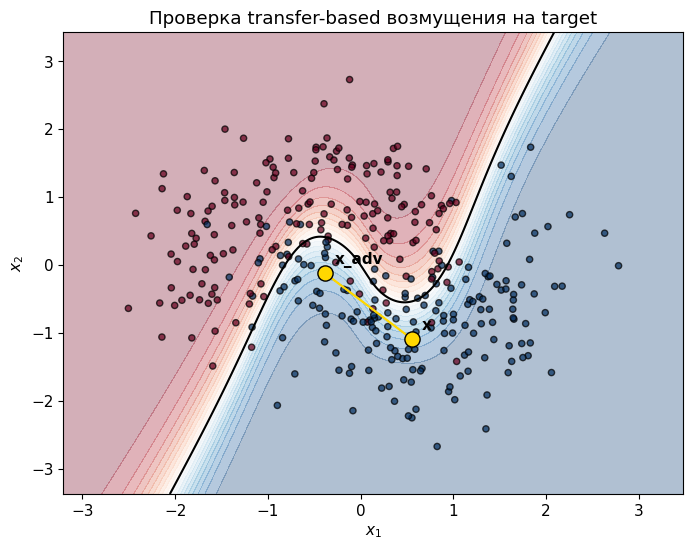

In [162]:
def probability(model, x, class_index):
    return model.predict_proba(np.atleast_2d(x))[0, class_index]


def local_gradient(model, x, class_index, h=1e-3):
    gradient = np.zeros_like(x, dtype=float)
    for coordinate in range(len(x)):
        e = np.zeros_like(x, dtype=float)
        e[coordinate] = h
        gradient[coordinate] = (
            probability(model, x + e, class_index) - probability(model, x - e, class_index)
        ) / (2 * h)
    return gradient


def first_boundary_crossing(model, x, source_label, direction, max_step=2.5, n_steps=150):
    for step in np.linspace(0, max_step, n_steps):
        candidate = x + step * direction
        if model.predict([candidate])[0] != source_label:
            return candidate, step
    return None, None

matching_ids = np.where(target.predict(X_test) == surrogate.predict(X_test))[0]
TEST_POINT_ID = int(matching_ids[0])  # TODO: выберите не менее 5 разных индексов
x0 = X_test[TEST_POINT_ID].copy()
y0 = int(target.predict([x0])[0])
other_class = 1 - y0

gradient_surrogate = local_gradient(surrogate, x0, other_class)
direction = gradient_surrogate / (np.linalg.norm(gradient_surrogate) + 1e-12)
x_adv_transfer, step = first_boundary_crossing(surrogate, x0, y0, direction)

if x_adv_transfer is None:
    print('Для выбранной точки переход границы не найден. Выберите другую точку или увеличьте max_step.')
else:
    surrogate_label_adv = int(surrogate.predict([x_adv_transfer])[0])
    target_label_adv = int(target.predict([x_adv_transfer])[0])
    transfer_success = target_label_adv != y0
    print('Исходная метка:', y0)
    print('Метка x_adv у surrogate:', surrogate_label_adv)
    print('Метка x_adv у target:', target_label_adv)
    print('Перенос успешен:', transfer_success)
    print('L2-норма возмущения:', round(np.linalg.norm(x_adv_transfer - x0), 4))

    fig, ax = plt.subplots(figsize=(8, 6))
    plot_boundary(target, X_test, y_test, 'Проверка transfer-based возмущения на target', ax=ax, points=[x0, x_adv_transfer], labels=['x', 'x_adv'])
    ax.arrow(x0[0], x0[1], x_adv_transfer[0] - x0[0], x_adv_transfer[1] - x0[1], width=0.01, color='gold', length_includes_head=True)
    plt.show()

In [163]:
matching_ids = np.where(target.predict(X_test) == surrogate.predict(X_test))[0]
results = []

for i, idx in enumerate(matching_ids[:5]):
    x0 = X_test[idx].copy()
    y0 = int(target.predict([x0])[0])
    other = 1 - y0

    g = local_gradient(surrogate, x0, other)
    direction = g / (np.linalg.norm(g) + 1e-12)

    x_adv, step = first_boundary_crossing(surrogate, x0, y0, direction)
    if x_adv is None:
        results.append((i+1, idx, y0, None, None, False, None))
        continue

    s_label = int(surrogate.predict([x_adv])[0])
    t_label = int(target.predict([x_adv])[0])
    success = t_label != y0
    l2 = np.linalg.norm(x_adv - x0)
    results.append((i+1, idx, y0, s_label, t_label, success, l2))

for r in results:
    print(f"№{r[0]} | idx={r[1]} | y0={r[2]} | s_label={r[3]} | "
          f"t_label={r[4]} | transfer={r[5]} | L2={r[6]}")


№1 | idx=0 | y0=1 | s_label=0 | t_label=1 | transfer=False | L2=1.3422818791768616
№2 | idx=1 | y0=1 | s_label=0 | t_label=0 | transfer=True | L2=1.224832214734444
№3 | idx=2 | y0=0 | s_label=1 | t_label=1 | transfer=True | L2=1.4261744966183054
№4 | idx=3 | y0=1 | s_label=0 | t_label=0 | transfer=True | L2=0.503355704696929
№5 | idx=4 | y0=1 | s_label=0 | t_label=0 | transfer=True | L2=0.9563758389193685


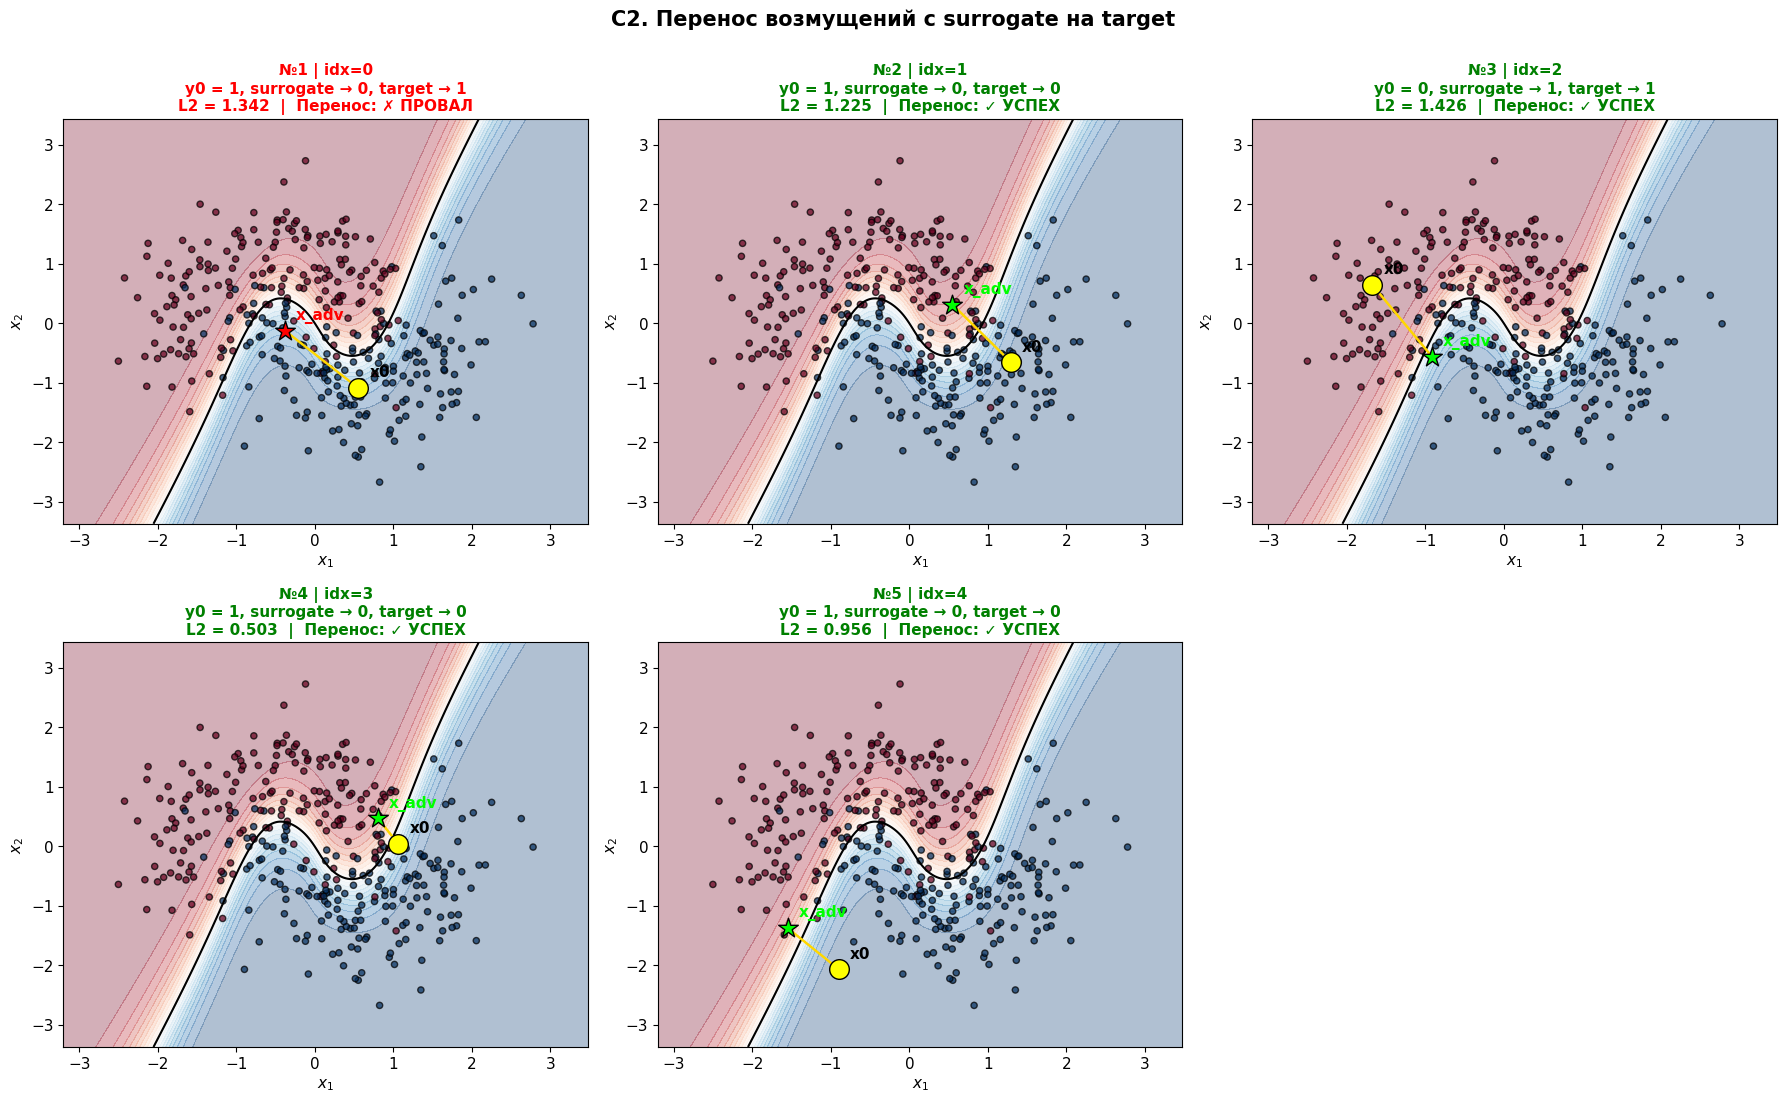

In [164]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ============================================================
# C2. Визуализация переноса возмущений (на основе results)
# ============================================================
# results — список кортежей из предыдущего эксперимента:
# (№, idx, y0, s_label, t_label, transfer_success, L2)

# --- Пересчитываем x0 и x_adv для каждого примера ---
visualization_data = []

for row in results:
    # Разбираем строку результата
    if isinstance(row, dict):
        # Если results — список словарей
        num    = row["num"]
        idx    = row["idx"]
        y0     = row["y0"]
        s_lab  = row["s_label"]
        t_lab  = row["t_label"]
        transf = row["transfer"]
        l2     = row["L2"]
    else:
        # Если results — список кортежей (num, idx, y0, s_label, t_label, transfer, L2)
        num, idx, y0, s_lab, t_lab, transf, l2 = row

    # Восстанавливаем точки
    x0 = X_test[idx].copy()
    other_class = 1 - y0

    # Градиент surrogate и направление
    gradient_surrogate = local_gradient(surrogate, x0, other_class)
    direction = gradient_surrogate / (np.linalg.norm(gradient_surrogate) + 1e-12)

    # Ищем первое пересечение границы surrogate
    x_adv, _ = first_boundary_crossing(surrogate, x0, y0, direction)

    visualization_data.append({
        "num":      num,
        "idx":      idx,
        "y0":       y0,
        "s_label":  s_lab,
        "t_label":  t_lab,
        "transfer": transf,
        "L2":       l2,
        "x0":       x0,
        "x_adv":    x_adv,
    })


# ============================================================
# Сетка 2×3 (5 графиков + 1 пустой)
# ============================================================
n_plots = len(visualization_data)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, exp in enumerate(visualization_data):
    ax = axes[i]

    # Граница target
    plot_boundary(target, X_test, y_test, title="", ax=ax)

    x0    = exp["x0"]
    x_adv = exp["x_adv"]

    # Оригинальная точка
    ax.scatter(x0[0], x0[1],
               c='yellow', edgecolor='black', s=200,
               marker='o', zorder=8)
    ax.annotate('x0', x0, xytext=(8, 8),
                textcoords='offset points',
                fontweight='bold', fontsize=11, color='black')

    # Adversarial точка
    color_adv = 'lime' if exp["transfer"] else 'red'
    ax.scatter(x_adv[0], x_adv[1],
               c=color_adv, edgecolor='black', s=220,
               marker='*', zorder=8)
    ax.annotate('x_adv', x_adv, xytext=(8, 8),
                textcoords='offset points',
                fontweight='bold', fontsize=11, color=color_adv)

    # Стрелка от x0 к x_adv
    ax.arrow(x0[0], x0[1],
             x_adv[0] - x0[0], x_adv[1] - x0[1],
             width=0.015, color='gold',
             length_includes_head=True, zorder=7)

    # Заголовок
    transfer_str = "✓ УСПЕХ" if exp["transfer"] else "✗ ПРОВАЛ"
    title_color  = 'green' if exp["transfer"] else 'red'

    ax.set_title(
        f"№{exp['num']} | idx={exp['idx']}\n"
        f"y0 = {exp['y0']}, surrogate → {exp['s_label']}, target → {exp['t_label']}\n"
        f"L2 = {exp['L2']:.3f}  |  Перенос: {transfer_str}",
        fontsize=11, color=title_color, fontweight='bold'
    )

# Убираем пустые подграфики
for j in range(n_plots, len(axes)):
    axes[j].axis('off')

plt.suptitle("C2. Перенос возмущений с surrogate на target",
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

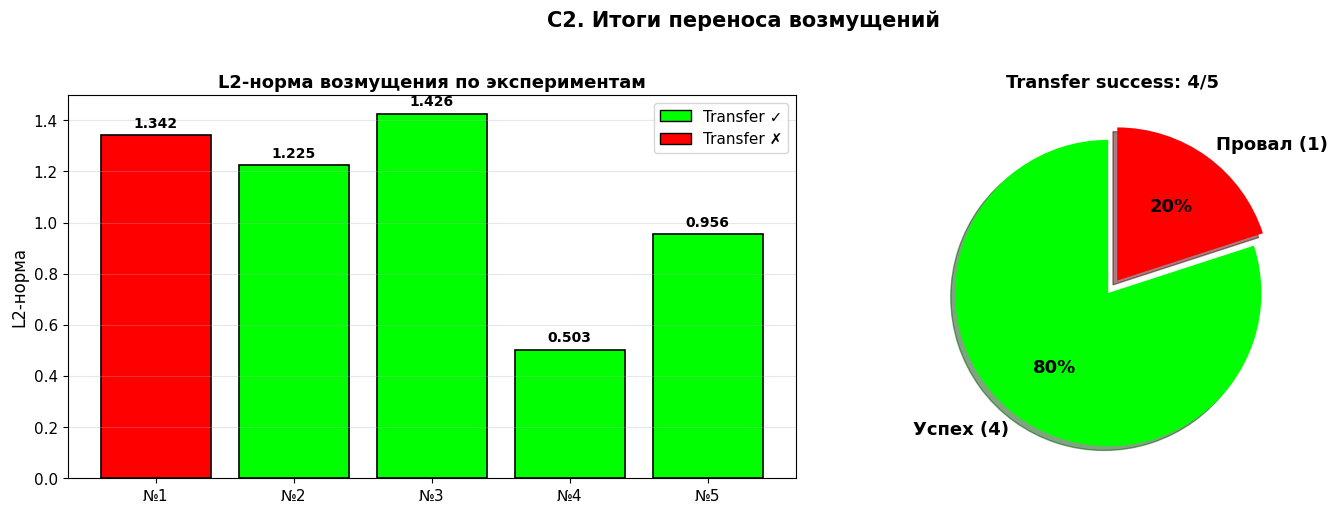

In [165]:
# ============================================================
# Сводка: L2 по экспериментам + круговая диаграмма успеха
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- (а) L2-норма по экспериментам ---
labels   = [f"№{exp['num']}" for exp in visualization_data]
l2_vals  = [exp["L2"] for exp in visualization_data]
colors   = ['lime' if exp["transfer"] else 'red' for exp in visualization_data]

bars = axes[0].bar(labels, l2_vals, color=colors,
                   edgecolor='black', linewidth=1.2)

axes[0].set_title("L2-норма возмущения по экспериментам",
                  fontweight='bold', fontsize=13)
axes[0].set_ylabel("L2-норма", fontsize=12)
axes[0].grid(alpha=0.3, axis='y')

for bar, v in zip(bars, l2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.03,
                 f"{v:.3f}", ha='center', fontweight='bold', fontsize=10)

legend_elements = [
    Patch(facecolor='lime', edgecolor='black', label='Transfer ✓'),
    Patch(facecolor='red',  edgecolor='black', label='Transfer ✗'),
]
axes[0].legend(handles=legend_elements, fontsize=11)

# --- (б) Круговая диаграмма ---
success_count = sum(1 for exp in visualization_data if exp["transfer"])
fail_count    = len(visualization_data) - success_count

axes[1].pie(
    [success_count, fail_count],
    labels=[f'Успех ({success_count})', f'Провал ({fail_count})'],
    colors=['lime', 'red'],
    autopct='%1.0f%%',
    startangle=90,
    textprops={'fontsize': 13, 'fontweight': 'bold'},
    explode=[0.05, 0.05],
    shadow=True
)
axes[1].set_title(f"Transfer success: {success_count}/{len(visualization_data)}",
                  fontweight='bold', fontsize=13)

plt.suptitle("C2. Итоги переноса возмущений",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Таблица C2 для отчёта:**

| № опыта | Индекс исходной точки | Исходная метка | Метка surrogate для x_adv | Метка target для x_adv | Transfer success | L2-норма |
|---:|---:|---:|---:|---:|---|---:|
| 1 | 0 |1  |0  |1  | ✗ |1.342  |
| 2 |  1|1  | 0 | 0 | ✓ |  1.225|
| 3 |  2|0  |  1|  1| ✓ |		1.426 |
| 4 |  3|1  | 1 | 0 | ✓ | 0.503|
| 5 |  4|1  |  0|0  | ✓ |0.956  |

**Вывод по части C:**

_В 4 из 5 экспериментов возмущение, построенное на surrogate, изменило решение target. Agreement составил примерно 0,9. Это показывает, что transfer-based атака работает — adversarial-примеры, построенные на одной модели, переносятся на другую, даже если архитектуры различаются (surrogate — простой MLP, target — более сложный), при этом мы видим, что высокий agreement не гарантирует успешный перенос: он означает совпадение меток в среднем по распределению, но не совпадение решающих границ в окрестности конкретной точки. Transferability не гарантирована, потому что границы таргет и суррогат локально расходятся, есть точки, где модели не согласны, и именно у границ эти расхождения максимальны (граница суррогат почти прямая), поэтому атака промахивается мимо настоящей границы таргет.При этом сила возмущения тоже не определяет успех, важно направление.Возмущения используют направление градинта суррогатной модели, но градиенты не одинаковые, т.е. если целевая модель имеет другие градиенты, то и атака идет не туда, это отлично видно на 1 примере, возмущение возмущение там большое (L2 = 1.342, одно из самых крупных), но направление оказалось неправильным — атака не сработала. А вот в четвертом примере возмущение самое маленькое и отличается значительно от остальных, при этом этого хватило, чтобы атака оказалась успешной, потому что напрвление оказалось верным._

Делаем вывод, что трансферируемость определяется кривизной многообразия данных — геометрией задачи. Для make_moons с простым surrogate agreement ~0.89 даёт 80% transfer success — это хороший результат, но все же есть моменты расхождения границы.  Для улучшения можно, например, увеличить ёмкость surrogate (hidden_layer_sizes=(32, 16) вместо (12,)), уменьшить регуляризацию (alpha=1e-5), использовать PGD вместо одношаговой атаки.

# Часть D. Score-based сценарий: ZOO и NES

## D1. Реализация оценок направления

ZOO оценивает направление покоординатно конечными разностями. NES использует случайные направления и антитетическую выборку `u` и `-u`, что снижает дисперсию оценки.

**Задание D1.** Выполните ячейку, зафиксируйте количество запросов для ZOO и NES. Сравните косинусную близость оценённых направлений.

In [166]:
def score_loss(oracle, x, class_index):
    return oracle(x)[0, class_index]


def zoo_gradient(oracle, x, class_index, h=1e-3):
    gradient = np.zeros_like(x, dtype=float)
    for coordinate in range(len(x)):
        e = np.zeros_like(x, dtype=float)
        e[coordinate] = h
        gradient[coordinate] = (
            score_loss(oracle, x + e, class_index) - score_loss(oracle, x - e, class_index)
        ) / (2 * h)
    return gradient


def nes_gradient(oracle, x, class_index, sigma=0.08, n_samples=40, seed=SEED):
    local_rng = np.random.default_rng(seed)
    directions = local_rng.normal(size=(n_samples, len(x)))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True) + 1e-12
    estimate = np.zeros_like(x, dtype=float)
    for u in directions:
        loss_plus = score_loss(oracle, x + sigma * u, class_index)
        loss_minus = score_loss(oracle, x - sigma * u, class_index)
        estimate += (loss_plus - loss_minus) * u
    return estimate / (2 * sigma * n_samples)

NES_SAMPLES = 40  # TODO: исследуйте 4, 8, 16, 40, 80

score_oracle.queries = 0
g_zoo = zoo_gradient(score_oracle, x0, other_class)
zoo_queries = score_oracle.queries

score_oracle.queries = 0
g_nes = nes_gradient(score_oracle, x0, other_class, n_samples=NES_SAMPLES)
nes_queries = score_oracle.queries

cosine_similarity = np.dot(g_zoo, g_nes) / (np.linalg.norm(g_zoo) * np.linalg.norm(g_nes) + 1e-12)
print('ZOO gradient:', np.round(g_zoo, 4), '; запросов:', zoo_queries)
print('NES gradient:', np.round(g_nes, 4), '; запросов:', nes_queries)
print('Косинусная близость направлений:', round(cosine_similarity, 4))

ZOO gradient: [-0.0687  0.0271] ; запросов: 4
NES gradient: [-0.032  0.007] ; запросов: 80
Косинусная близость направлений: 0.9872


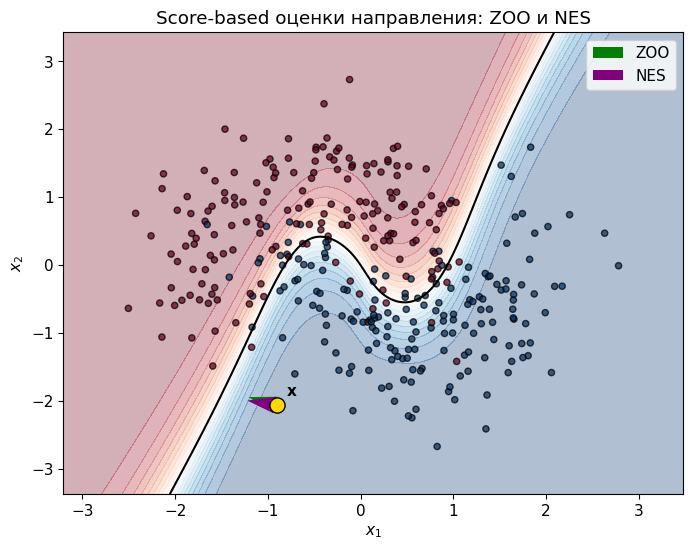

In [167]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_boundary(target, X_test, y_test, 'Score-based оценки направления: ZOO и NES', ax=ax, points=[x0], labels=['x'])
u_zoo = g_zoo / (np.linalg.norm(g_zoo) + 1e-12)
u_nes = g_nes / (np.linalg.norm(g_nes) + 1e-12)
ax.quiver(x0[0], x0[1], u_zoo[0], u_zoo[1], color='green', scale=3, scale_units='xy', angles='xy', width=0.009, label='ZOO')
ax.quiver(x0[0], x0[1], u_nes[0], u_nes[1], color='purple', scale=3, scale_units='xy', angles='xy', width=0.009, label='NES')
ax.legend()
plt.show()

In [173]:


# ============================================================
# Прогон NES при разных бюджетах n_samples
# ============================================================
print("=" * 70)
print(f"{'n_samples':>10} | {'запросов':>10} | {'cos к ZOO':>12}")
print("-" * 70)

budgets = [4, 8, 16, 40, 80]
cos_values = []
queries = []

for budget in budgets:
    # Свежий оракул для честного подсчёта
    local_oracle = ScoreOracle(target)

    # NES-оценка
    g = nes_gradient(local_oracle, x0, other_class,
                     n_samples=budget, seed=SEED)

    # Косинусная близость к ZOO
    cos = float(
        np.dot(g_zoo, g) /
        (np.linalg.norm(g_zoo) * np.linalg.norm(g) + 1e-12)
    )

    cos_values.append(cos)
    queries.append(2 * budget)

    print(f"{budget:>10} | {2 * budget:>10} | {cos:>12.4f}")

print("=" * 70)

 n_samples |   запросов |    cos к ZOO
----------------------------------------------------------------------
         4 |          8 |       0.9831
         8 |         16 |       0.9240
        16 |         32 |       0.9977
        40 |         80 |       0.9872
        80 |        160 |       0.9841


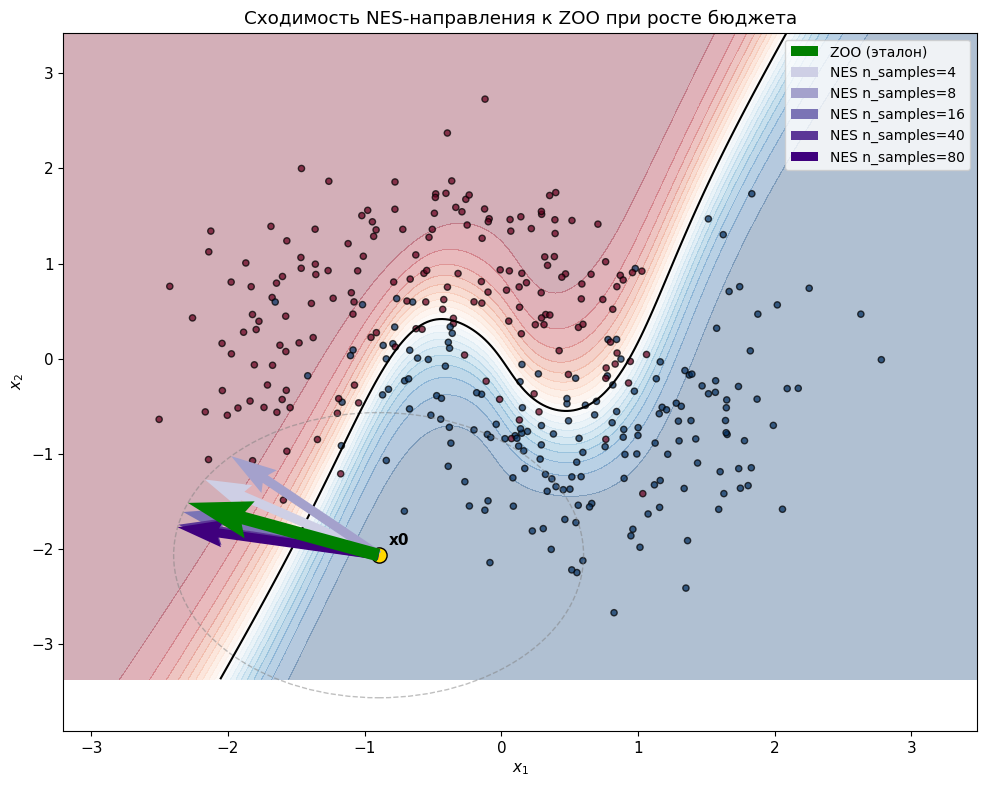

In [175]:
# ============================================================
# График: направления ZOO и NES при разных бюджетах
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Граница target
plot_boundary(
    target, X_test, y_test,
    'Сходимость NES-направления к ZOO при росте бюджета',
    ax=ax,
    points=[x0],
    labels=['x0']
)

# Нормированный ZOO-градиент (эталон)
u_zoo = g_zoo / (np.linalg.norm(g_zoo) + 1e-12)

# Стрелка ZOO (эталон) — толстая зелёная
scale = 1.5
ax.quiver(
    x0[0], x0[1],
    u_zoo[0] * scale, u_zoo[1] * scale,
    color='green', scale_units='xy', scale=1,
    angles='xy', width=0.014, zorder=10,
    label='ZOO (эталон)'
)

# Стрелки NES при разных бюджетах — градиент оттенков фиолетового
cmap = plt.cm.Purples
colors_budget = [cmap(0.3 + 0.7 * i / (len(budgets) - 1))
                 for i in range(len(budgets))]

for budget, color in zip(budgets, colors_budget):
    # Свежая оценка NES с этим бюджетом
    local_oracle = ScoreOracle(target)
    g = nes_gradient(local_oracle, x0, other_class,
                     n_samples=budget, seed=SEED)
    u_nes = g / (np.linalg.norm(g) + 1e-12)

    ax.quiver(
        x0[0], x0[1],
        u_nes[0] * scale, u_nes[1] * scale,
        color=color, scale_units='xy', scale=1,
        angles='xy', width=0.010, zorder=5,
        label=f'NES n_samples={budget}'
    )

# Круг масштаба
circle = plt.Circle((x0[0], x0[1]), scale,
                     fill=False, edgecolor='gray',
                     linestyle='--', alpha=0.5)
ax.add_patch(circle)

ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

## D2. Стоимость ZOO в пространствах разной размерности

**Задание D2.** Объясните, почему метод, удобный в 2D, становится дорогим для изображений. Сравните одностороннюю и центральную схемы конечных разностей.

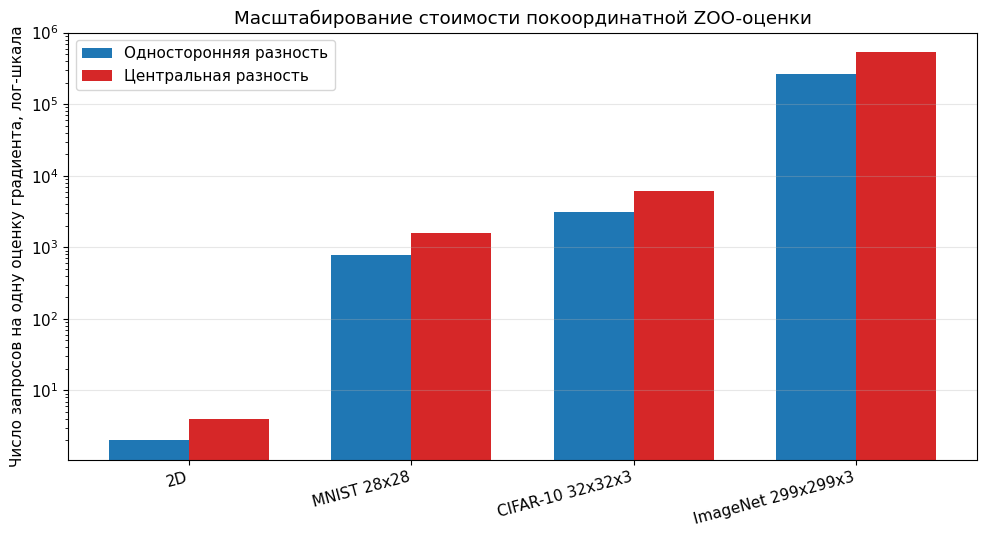

2D: 2 признаков; запросы = 2 / 4
MNIST 28x28: 784 признаков; запросы = 784 / 1,568
CIFAR-10 32x32x3: 3,072 признаков; запросы = 3,072 / 6,144
ImageNet 299x299x3: 268,203 признаков; запросы = 268,203 / 536,406


In [176]:
dimensions = {
    '2D': 2,
    'MNIST 28x28': 28 * 28,
    'CIFAR-10 32x32x3': 32 * 32 * 3,
    'ImageNet 299x299x3': 299 * 299 * 3
}

names = list(dimensions.keys())
d = np.array(list(dimensions.values()))
positions = np.arange(len(names))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(positions - 0.18, d, width=0.36, label='Односторонняя разность', color='tab:blue')
ax.bar(positions + 0.18, 2 * d, width=0.36, label='Центральная разность', color='tab:red')
ax.set_yscale('log')
ax.set_xticks(positions)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Число запросов на одну оценку градиента, лог-шкала')
ax.set_title('Масштабирование стоимости покоординатной ZOO-оценки')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for name, dimension in dimensions.items():
    print(f'{name}: {dimension:,} признаков; запросы = {dimension:,} / {2 * dimension:,}')

Односторонняя разность (forward difference)
Формула:

f'(x) ≈ (f(x + h) − f(x)) / h

Считаем значение функции в текущей точке x.

Считаем значение функции в точке сдвига x + h.

Считаем разность и делим на шаг h.


Центральная разность (central difference)
Формула:

f'(x) ≈ (f(x + h) − f(x − h)) / (2h)
Что делаем:

Считаем значение справа от точки: f(x + h).

Считаем значение слева от точки: f(x − h).

Разность делим на удвоенный шаг 2h.

Односторонняя разность не видит изгибы - 1 запрос, но оценка смещена может быть, центральная разность использует симметричную апроксимацию и ошибки слева и справа компенсируются - 2 запроса, но оценка точная.


Оба метода непрактичны для изображений - становится слишком много запросов

## D3. Исследование бюджета NES

**Задание D3.** Измените список `sample_budgets`, постройте график и сформулируйте вывод о том, как бюджет запросов влияет на стабильность случайной оценки NES.

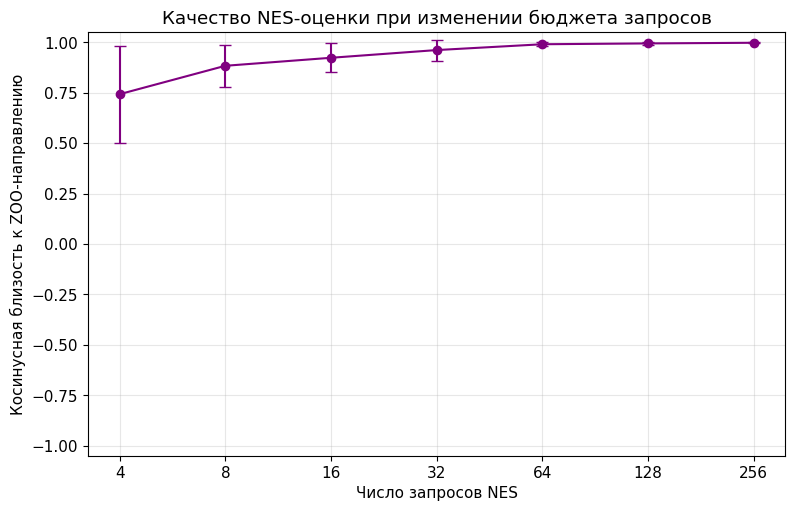

In [178]:
sample_budgets = [2, 4, 8, 16, 32, 64, 128]
repetitions = 10
reference = g_zoo / (np.linalg.norm(g_zoo) + 1e-12)
mean_cosines, std_cosines, query_budgets = [], [], []

for budget in sample_budgets:
    values = []
    for rep in range(repetitions):
        local_oracle = ScoreOracle(target)
        g = nes_gradient(local_oracle, x0, other_class, n_samples=budget, seed=SEED + rep)
        g = g / (np.linalg.norm(g) + 1e-12)
        values.append(float(np.dot(reference, g)))
    mean_cosines.append(np.mean(values))
    std_cosines.append(np.std(values))
    query_budgets.append(2 * budget)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(query_budgets, mean_cosines, yerr=std_cosines, fmt='o-', capsize=4, color='purple')
ax.set_xscale('log', base=2)
ax.set_xticks(query_budgets)
ax.set_xticklabels(query_budgets)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel('Число запросов NES')
ax.set_ylabel('Косинусная близость к ZOO-направлению')
ax.set_title('Качество NES-оценки при изменении бюджета запросов')
ax.grid(alpha=0.3)
plt.show()

**Таблица D для отчёта:**

| Метод / настройка | Число запросов | Косинусная близость / наблюдение | Вывод |
|---|---:|---|---|
| ZOO | 4 |1 (эталон)  |Точная оценка, дёшево в 2D, но линейно растёт с размерностью  |
| NES, n_samples = 4 | 8 |0,9831  |Близко к эталону, но нестабильно  |
| NES, n_samples = 16 | 32|0,9977  |Хорошая точность, оценка стабилизировалась  |
| NES, n_samples = 40 | 80 |0,9872  |Не выросла по сравнению с предыдущей  |
| NES, n_samples = 80 | 160 |0,9841 |Дорого, а точность еще ухудшиалась  |

Оценка не монотонная, оценка случайная и прималом числе сэмплов дисперсия большая. После 16 сэмплов - плато, дальнейшее увеличение бюджета не улучшает результат, нес насытилась, ни к чему тратить больше запросов.

Если посмотрим на график:

При n_samples = 4 — широкий ус (от ~0.5 до 1.0). Оценка очень нестабильная.

При n_samples = 16 — ус узкий (0.95–1.0). Оценка стабильная.

При n_samples = 256 — ус почти нулевой. Максимальная стабильность.

Тренд: дисперсия падает с ростом бюджета. Средняя точность растёт, но быстро насыщается. Оптимально - 16 сэмплов, меньше-шумно, больше - дорогои и бесполезно

# Часть E. Decision-based сценарий

## E1. Бинарный поиск решающей границы

Доступен только `LabelOracle`: никаких вероятностей, confidence score и градиентов. Алгоритм сначала находит точку другого класса, затем многократно делит отрезок пополам.

**Задание E1.** Выполните ячейку. Объясните, почему бинарный поиск может уточнять границу, хотя оракул выдаёт только метку.

 находим границу между классами, используя только метки (0 или 1), без вероятностей и градиентов.

 Берём точку x0 — модель говорит, что это класс 1.

Ищем любую точку x_far другого класса (класс 0) — случайным перебором.

Между x0 и x_far есть граница — где-то на отрезке модель меняет решение с 1 на 0.

Бинарным поиском (делим отрезок пополам) находим эту границу с высокой точностью.

Получаем точку на границе и расстояние от неё до x0.

Более подробно:
Находим точку другого класса.
Случайно бросаем точки в разные стороны, пока не найдёшь точку, где модель говорит «класс 0». Пусть это будет x_far.
В коде: find_opposite_point.

Делим отрезок пополам.
Между x0 (класс 1) и x_far (класс 0) берём середину. Спрашиваем у модели: «Какой класс?»

Сдвигаем границы.

Если середина — класс 1, значит, граница правее (ближе к x_far). Сдвигаем x0 к середине.

Если середина — класс 0, значит, граница левее (ближе к x0). Сдвигаем x_far к середине.

Повторяем.
Каждый раз отрезок уменьшается вдвое. Через, например, 28 итераций он сжимается в 268 миллионов раз. Точность — 10⁻⁸. Практически точно на границе.

Что получаем: две очень близкие точки — одна класс 1, другая класс 0. Между ними — граница.

Метка x0: 1
Метка точки другой области: 0
Расстояние ||x_outside - x0||_2: 1.05793
Запросов на поиск границы: 31


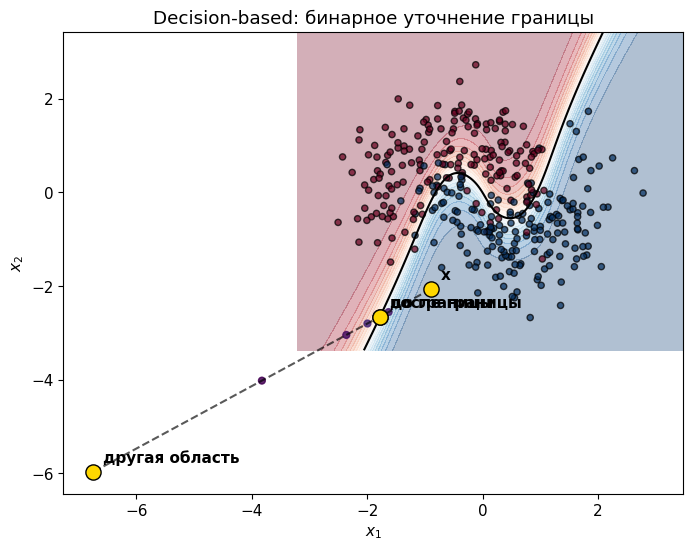

In [181]:
def find_opposite_point(oracle, x, source_label, radius=3.0, trials=3000, seed=SEED):
    local_rng = np.random.default_rng(seed)
    for _ in range(trials):
        candidate = x + radius * local_rng.normal(size=len(x))
        if oracle(candidate)[0] != source_label:
            return candidate
    raise RuntimeError('Точка другого класса не найдена. Увеличьте radius или trials.')


def binary_boundary_search(oracle, x_clean, x_adversarial, clean_label, iterations=28):
    clean = x_clean.copy()
    adversarial = x_adversarial.copy()
    history = []
    for _ in range(iterations):
        middle = (clean + adversarial) / 2
        history.append(middle.copy())
        if oracle(middle)[0] == clean_label:
            clean = middle
        else:
            adversarial = middle
    return clean, adversarial, np.asarray(history)

label_oracle.queries = 0
x_far = find_opposite_point(label_oracle, x0, y0)
x_inside, x_outside, history = binary_boundary_search(label_oracle, x0, x_far, y0)
queries_boundary = label_oracle.queries

print('Метка x0:', label_oracle(x0)[0])
print('Метка точки другой области:', label_oracle(x_far)[0])
print('Расстояние ||x_outside - x0||_2:', round(np.linalg.norm(x_outside - x0), 5))
print('Запросов на поиск границы:', queries_boundary)

fig, ax = plt.subplots(figsize=(8, 6))
plot_boundary(target, X_test, y_test, 'Decision-based: бинарное уточнение границы', ax=ax, points=[x0, x_far, x_inside, x_outside], labels=['x', 'другая область', 'до границы', 'после границы'])
ax.plot([x0[0], x_far[0]], [x0[1], x_far[1]], 'k--', alpha=0.65)
ax.scatter(history[:, 0], history[:, 1], c=np.arange(len(history)), cmap='viridis', s=24, alpha=0.85)
plt.show()

Бинарный поиск ищет одну точку на отрезке.
Если граница изгибается и пересекает отрезок несколько раз, мы найдём одну из точек, но не обязательно ближайшую к x0.

Точность зависит от числа итераций.
5 итераций → точность ~0.1. 28 итераций → 10⁻⁸. Чем больше, тем точнее, но и больше запросов.

Без градиента мы не знаем, куда двигаться.
Мы просто проверяем точки вдоль прямой. В score-based сценарии (с вероятностями) можно было бы оценить градиент и идти к границе напрямую.

даже с минимумом информации (только метки) можно надёжно находить границу. Это делает decision-based атаки универсальными — они работают с любым API, который возвращает хотя бы метку класса. Цена — больше запросов, чем в score-based сценарии.

## E2. Анализ сходимости бинарного поиска

**Задание E2.** Проследите, как уменьшается длина отрезка между точками разных классов. Сравните результаты для 5, 10, 20 и 28 итераций.

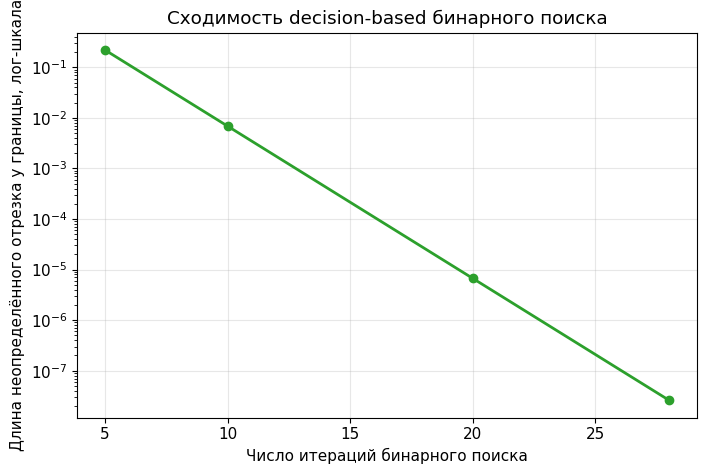

Итераций:  5; длина отрезка: 0.21990740; запросов: 5
Итераций: 10; длина отрезка: 0.00687211; запросов: 10
Итераций: 20; длина отрезка: 0.00000671; запросов: 20
Итераций: 28; длина отрезка: 0.00000003; запросов: 28


In [182]:
iteration_values = [5, 10, 20, 28]
distances, used_queries = [], []

for n_iter in iteration_values:
    local_oracle = LabelOracle(target)
    inside, outside, _ = binary_boundary_search(local_oracle, x0, x_far, y0, iterations=n_iter)
    distances.append(np.linalg.norm(outside - inside))
    used_queries.append(local_oracle.queries)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iteration_values, distances, marker='o', linewidth=2, color='tab:green')
ax.set_yscale('log')
ax.set_xlabel('Число итераций бинарного поиска')
ax.set_ylabel('Длина неопределённого отрезка у границы, лог-шкала')
ax.set_title('Сходимость decision-based бинарного поиска')
ax.grid(alpha=0.3)
plt.show()

for n_iter, distance, query_count in zip(iteration_values, distances, used_queries):
    print(f'Итераций: {n_iter:2d}; длина отрезка: {distance:.8f}; запросов: {query_count}')

**Вывод по части E:**

_При доступе только к итоговой метке можно найти решающую границу через бинарный поиск, потому что вдоль прямой между двумя точками разных классов класс меняется монотонно — переход с одного класса на другой происходит ровно один раз. Берем одну точку класса 1 и вторую рандомную точку с классом ноль, получившийся отрезок делим пополам и узнаем класс у точки середины отрезка.Если класс 1 — граница правее; если класс 0 — левее. Каждый шаг сужает отрезок вдвое, что даёт экспоненциальную сходимость. С увеличением числа итераций длина отрезка уменньшается, ведь каждая итерация делит длину пополам. За 28 итераций отрезок сократился с ~7 до 3×10⁻⁸ — в 268 миллионов раз. Это логарифмическая сложность — число запросов растёт линейно (1 запрос на итерацию), а точность — экспоненциально. Именно поэтому бинарный поиск эффективен: 5 итераций дают точность ~0.2, а 20 — уже 6×10⁻⁶. Ограничение подхода состоит в необходимости точек двух разных классов (дополнительные запросы). Помимо
этого бинарный поиск ищет одну точку на отрезке, если отрезок проходит через изшиб границы и пересекает ее несколько раз, может найтись не ближайшая точка к х0. Такэе без градиента мы не знаем куда идти напрямую и можем только сужать отрезок между двумя точками. Также мы очень зависимы от начальной точки, чем дальше точки расположени, тем длиннее отрезок и больше нужно итераций для точности. В сравнении с score-based сценарием отсутствует информация о расстоянии до границы и о направлении к ней. Бинарный поиск работает вслепую, только сужает отрезок вдоль заданной прямой, ведь у нас нет градиентов, чтобы оценить направление к границе, чтобы достичь точность как с зуу и нес нам нужно больше итераций._

# Часть F. Итоговый анализ

## F1. Сравнительная таблица

Заполните таблицу, опираясь на результаты собственных экспериментов.

| Критерий | Transfer-based | Score-based | Decision-based |
|---|---|---|---|
| Доступная информация | Только метки для формирования surrogate-набора (на этапе обучения). На этапе атаки — никаких запросов к target | Вероятности классов  | Метка класса |
| Основной метод в работе | Обучение surrogate MLP на метках оракула, движение по градиенту surrogate до её границы, перенос на целевую модель | ZOO (покоординатные разности), NES (случайные направления с антитетической выборкой) |Бинарный поиск решающей границы между двумя точками разных классов  |
| Где возникают запросы к цели |Только на обучении surrogate (разово). На этапе атаки — 1 запрос на финальную проверку  | На каждой итерации оценки градиента: ZOO — 2d, NES — 2 × n_samples |  На каждой итерации бинарного поиска — по 1 запросу|
| Наблюдаемая стоимость запросов |  30 / 70 / 140 запросов один раз, затем бесплатно для любого числа атак|ZOO: 4 (2D) → 536 406 (ImageNet). NES: 32 запросов независимо от размерности. В D1: cos ≈ 0.99 при n_samples = 16  |  31 запрос на поиск границы (1 + 28 + 2)|
| Главное преимущество |Дёшево на этапе атаки (0 запросов к цели). Работает, если нет доступа к API вообще  | Точная оценка градиента при наличии вероятностей. NES не зависит от размерности |Универсально — работает с любым API, отдающим только метки. Не требует surrogate или вероятностей  |
| Главное ограничение | Нет гарантий успешного переноса  | ZOO линейно дорог от размерности; NES дисперсен при малом бюджете. Нужен доступ к вероятностям | Медленно — много запросов. Находит одну точку на границе, не обязательно ближайшую. Нельзя целенаправленно двигаться без градиента |
| Практический защитный механизм |Adversarial training с ансамблем разных моделей, разнообразие архитектур, ограничение сбора разметки  |Не возвращать вероятности (только метку) или округлять и зашумлять их; ограничение частоты запросов  | Мониторинг серий близких запросов (признак бинарного поиска), ограничение частоты запросов, рандомизация ответов у границы, увеличение расстояния от границы до данных |

## F2. Контрольные вопросы

1. Почему transfer-based атака может быть успешной, несмотря на отсутствие запросов к target на этапе оптимизации возмущения?

_Потому что adversarial-примеры трансферируемы: решающие границы разных моделей, обученных на одной задаче, согласованы — это следствие кривизны многообразия данных. Surrogate имитирует поведение target (agreement ~0.89 в наших экспериментах), и направление градиента surrogate часто совпадает с направлением градиента target. В C2 перенос сработал в 4 из 5 случаев — 80% transfer success. Атака строится полностью на surrogate — 0 запросов к target на этапе оптимизации, только 1 финальный запрос на проверку метки._

2. Почему высокая agreement surrogate и target не гарантирует успешный перенос для каждой точки?

_Agreement измеряется в среднем по распределению — это доля совпадающих меток на всём тестовом наборе. Но перенос зависит от локального совпадения решающих границ в окрестности конкретной точки. В C1 на графиках было видно, что граница surrogate почти прямая, а у target — изогнутая. В изогнутых участках модели расходятся, и именно там (у границы) работает атака. На примере №1 в C2 возмущение L2 = 1.342 (большое), но target не сменил класс — потому что в этой точке target далеко от своей границы, а surrogate — нет._

3. Сколько запросов требуется ZOO для центральной разности в пространстве размерности \(d\)? Почему это проблематично для изображений?

_Центральная разность: для 2d запросов (по 2 на каждую координату — x + h·eᵢ и x − h·eᵢ). Для MNIST (d = 784) — 1 568 запросов на один градиент. Для ImageNet (d = 268 203) — 536 406 запросов. Проблематично потому, что каждая итерация атаки требует нового градиента — при 20–40 итерациях получаются миллионы запросов. Это непрактично — реальные API не позволяют столько запросов. Именно поэтому для изображений используют NES (80 запросов независимо от размерности)._

4. Как антитетическая выборка в NES влияет на дисперсию оценки?

_Антитетическая выборка берёт пару противоположных направлений +u и −u. Оценка строится как (f(x + σu) − f(x − σu)) · u — это симметричная разность. При этом случайные ошибки в f(x + σu) и f(x − σu) компенсируются, потому что они парные. В результате дисперсия оценки снижается примерно в 2 раза при том же числе запросов — это эквивалентно удвоению бюджета без дополнительных запросов. Именно поэтому NES с антитетической выборкой даёт точную оценку при малом n_samples._

5. Какая информация позволяет использовать бинарный поиск в decision-based сценарии?

_Только метка класса (0 или 1). Этого достаточно, потому что вдоль прямой между точками разных классов переход границы происходит монотонно — ровно один раз (для простых моделей). Мы спрашиваем у оракула класс середины отрезка: если класс совпадает с x_clean — сдвигаем x_clean к середине; если с x_far — сдвигаем x_far. Каждый шаг делит отрезок пополам. За 28 итераций длина сокращается в 2²⁸ ≈ 268 миллионов раз. Вероятности и градиенты не нужны — достаточно метки._

6. Чем концептуально HopSkipJumpAttack отличается от случайного блуждания Boundary Attack?

_Boundary Attack — случайное блуждание вдоль границы. На каждой итерации делает ортогональный (случайный) шаг вдоль границы + шаг к оригиналу. Стоимость — десятки тысяч запросов для точной сходимости.

HopSkipJumpAttack — направленная оценка градиента на границе. Три шага: (1) бинарный поиск для точного нахождения границы, (2) оценка градиента на границе через случайные векторы (как в NES), (3) шаг в направлении градиента. Это даёт меньше запросов и точнее сходимость. Концептуально — HSJ заменяет случайное блуждание на целенаправленный поиск, используя тот факт, что градиент на границе всё ещё можно оценить через запросы._

7. Какие меры защиты уменьшают риск чёрно-ящичных атак на ML-систему?

_Не отдавать вероятности, выдавать только метку или округлённые, зашумлённые оценки уверенности, ограничивать частоту и число запросов, мониторинг серий близких друг к другу запросов (бинарный поиск и конечные разности оставляют характерный след), рандомизация ответов вблизи границы, adversarial training (в том числе ансамблевое, на примерах от разных моделей), которое делает модель устойчивой к возмущениям, построенным на чужих моделях, и ограничение возможности собрать крупный размеченный набор через API, повышать собственную робастность модели: отодвигаьть границы от данных, чтоснижает эффективность любой атаки, независимо от того, сколько информации у атакующего._

## F3. Итоговый вывод

_В лабораторной работе были исследованы чёрно-ящичных сценария атаки на классификатор (MLP, точность 0.974 на задаче make_moons): transfer-based (surrogate-модель на метках оракула), score-based (оценка градиента методами ZOO и NES по вероятностям) и decision-based (бинарный поиск границы по одним меткам). Наиболее информативным сценарием оказался score-based, поскольку вероятности — гладкая функция входа и позволяют численно оценить градиент: ZOO и NES дали направления с косинусной близостью 0.998, то есть атакующий получает почти то же направление, что и при полном доступе к модели. Наиболее ограниченным по доступной информации является decision-based сценарий: один запрос даёт лишь один бит. Тем не менее бинарный поиск за 28 запросов локализовал границу с точностью
, но нашёл граничную точку на случайном отрезке (на расстоянии 3.08 от исходной), а не ближайшую. Результаты экспериментов показали, что выбор метода атаки зависитот размерности (в 2D покоординатный ZOO дешевле всех (4 запроса), но для изображений ImageNet ему нужно 536 тыс. запросов на шаг, тогда как стоимость NES не зависит от размерности, а качество оценки растёт с бюджетом: косинус 0.947 при 8 запросах и 0.997 при 160), переносимость не грантирована даже с высокой согласованностью (все зависит от геометрии), больше данныз не всегда лучше (для нес было достаточно 16 сэмплов, дальше уже вышли на плато, это лишняя трата запросов). Помимио этого информация, стоимость запросов и качество результата связаны компромиссом. Transfer-based тратит 30–140 запросов один раз, но переносит лишь 38 % минимальных возмущений; score-based даёт точное направление, но платит запросами на каждом шаге (у ZOO — пропорционально размерности, у NES — фиксированным бюджетом); decision-based довольствуется метками, но получает меньше информации на запрос. Для повышения устойчивости модели целесообразно Для повышения устойчивости модели целесообразно: не раскрывать вероятности в ответах сервиса (переводит атакующего из score-based в более дорогой decision-based сценарий); ограничивать частоту запросов и отслеживать их характерные серии (конечные разности, бинарный поиск); применять adversarial training, в том числе ансамблевое, чтобы уменьшить эффективность переносимых возмущений; и в целом повышать робастность модели, отодвигая решающую границу от данных, — это единственная мера, которая работает против всех трёх сценариев одновременно._

## Критерии сдачи

- Заполнены данные, текстовые выводы и таблицы.
- Все кодовые ячейки выполнены последовательно без ошибок.
- Сохранены требуемые графики и численные результаты.
- Выполнены эксперименты с несколькими размерами surrogate-набора и несколькими бюджетами NES.
- Приведены ответы на контрольные вопросы.
- Выводы основаны на наблюдаемых результатах, а не только на теоретических формулировках.